# Vacuum PMNS examples

This notebook gathers two examples from the `examples/` directory:

- `vacuum_pmns.py`: vacuum oscillation probabilities for an initial `nu_mu` beam.
- `vacuum_pmns_variable.py`: comparison between normal ordering and inverted ordering.

The notebook can be executed either from the repository root or from `notebooks/`.

In [28]:
from pathlib import Path
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from nu_waves.models.mixing import Mixing
from nu_waves.models.spectrum import Spectrum
from nu_waves.hamiltonian import vacuum
from nu_waves.globals.backend import Backend
from nu_waves.propagation.oscillator import NeutrinoEvent, NeutrinoEventBatch, Oscillator
import nu_waves.utils.flavors as flavors
import nu_waves.utils.style


## Shared configuration

We initialize here the 3-flavor PMNS mixing setup and the mass spectrum used by both examples.

In [29]:
# import torch
# Backend.set_api(torch, device="mps")
# Backend.set_api(torch, device="cpu")

# import jax
# Backend.set_api(jax, device="mps")
# Backend.set_api(jax, device="cpu")

angles = {(1, 2): np.deg2rad(33.4), (1, 3): np.deg2rad(8.6), (2, 3): np.deg2rad(49)}
phases = {(1, 3): np.deg2rad(195)}
dm2 = {(2, 1): 7.42e-5, (3, 2): 0.0024428}

def build_vacuum_oscillator(dm2_override=None):
    dm2_local = dict(dm2)
    if dm2_override is not None:
        dm2_local.update(dm2_override)

    h = vacuum.Hamiltonian(
        mixing=Mixing(n_neutrinos=3, mixing_angles=angles, dirac_phases=phases),
        spectrum=Spectrum(n_neutrinos=3, m_lightest=0, dm2=dm2_local),
        antineutrino=False,
    )
    return Oscillator(hamiltonian=h)


## 1. Reproduction of `vacuum_pmns.py`

Compute the oscillation probabilities for an initial `nu_mu` beam over a 295 km baseline.

In [30]:
osc = build_vacuum_oscillator()

n_points = int(1e5)
E_min, E_max = 0.2, 3.0
Enu_list = np.linspace(E_min, E_max, n_points)

t0 = time.perf_counter()
P = osc.probability(
    L_km=295,
    E_GeV=Enu_list,
    flavor_emit=flavors.muon,
    flavor_det=[flavors.electron, flavors.muon, flavors.tau],
)
t1 = time.perf_counter()

print(f"Execution time: {t1 - t0:.3f} s")
print(f"Output shape: {P.shape}")


Execution time: 0.024 s
Output shape: (100000, 3)


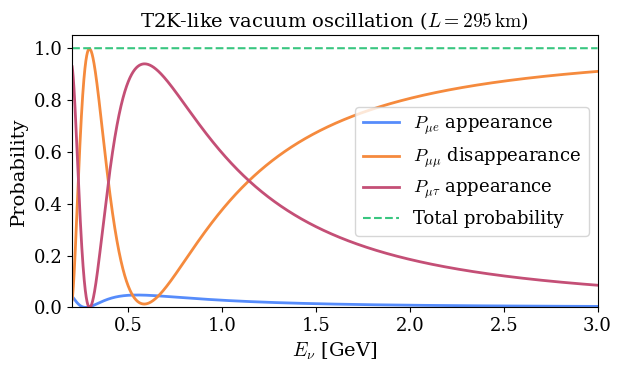

In [31]:
plt.figure(figsize=(6.5, 4.0))
plt.plot(Enu_list, P[:, flavors.electron], label=r"$P_{\mu e}$ appearance", lw=2)
plt.plot(Enu_list, P[:, flavors.muon], label=r"$P_{\mu\mu}$ disappearance", lw=2)
plt.plot(Enu_list, P[:, flavors.tau], label=r"$P_{\mu\tau}$ appearance", lw=2)
plt.plot(Enu_list, P.sum(axis=1), "--", label="Total probability", lw=1.5)
plt.xlabel(r"$E_\nu$ [GeV]")
plt.ylabel("Probability")
plt.title(r"T2K-like vacuum oscillation ($L=295\,\mathrm{km}$)")
plt.xlim(E_min, E_max)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


## 2. Reproduction of `vacuum_pmns_variable.py`

Here we compare `P(nu_mu -> nu_e)` for two spectrum choices: normal ordering and inverted ordering.

In [32]:
osc_no = build_vacuum_oscillator()
osc_io = build_vacuum_oscillator(dm2_override={(3, 2): -0.0024428})

E_min, E_max = 0.2, 3.0
Enu_list = np.linspace(E_min, E_max, 200)

P_no = osc_no.probability(
    L_km=295,
    E_GeV=Enu_list,
    flavor_emit=flavors.muon,
    flavor_det=flavors.electron,
)

P_io = osc_io.probability(
    L_km=295,
    E_GeV=Enu_list,
    flavor_emit=flavors.muon,
    flavor_det=flavors.electron,
)


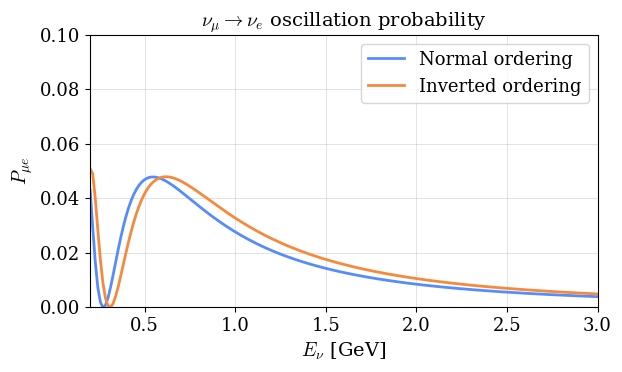

In [33]:
plt.figure(figsize=(6.5, 4.0))
plt.plot(Enu_list, P_no, label="Normal ordering", lw=2)
plt.plot(Enu_list, P_io, label="Inverted ordering", lw=2)
plt.xlabel(r"$E_\nu$ [GeV]")
plt.ylabel(r"$P_{\mu e}$")
plt.title(r"$\nu_\mu \rightarrow \nu_e$ oscillation probability")
plt.xlim(E_min, E_max)
plt.ylim(0, 0.1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. Event spectra for a T2K-like beam

We build here a `nu_mu` Monte Carlo sample using a toy T2K-like beam spectrum, peaked around `0.6 GeV` with a broader high-energy tail.

The same `E_nu_true` events are then propagated into two channels:

- disappearance `nu_mu -> nu_mu`
- appearance `nu_mu -> nu_e`

The histograms are drawn as a function of `E_nu_true`, with event-by-event oscillation probabilities used as weights. Both channels are computed in a single call to `osc_events.probability`.

In [34]:
osc_events = build_vacuum_oscillator()

rng = np.random.default_rng(42)

n_events = 60000
E_min, E_max = 0.2, 3.0
beam_grid = np.linspace(E_min, E_max, 1200)

# Toy T2K-like spectrum: narrow peak around 0.6 GeV and a broader secondary tail.
beam_flux = (
    0.85 * np.exp(-0.5 * ((beam_grid - 0.62) / 0.16) ** 2)
    + 0.15 * np.exp(-0.5 * ((beam_grid - 1.15) / 0.35) ** 2)
)
beam_pdf = beam_flux / beam_flux.sum()

E_nu_true = rng.choice(beam_grid, size=n_events, p=beam_pdf)
L_true_km = np.full(n_events, 295.0)
hist_bins = np.linspace(E_min, E_max, 29)

event_batch_all = NeutrinoEventBatch(
    L_km=np.concatenate([L_true_km, L_true_km]),
    E_GeV=np.concatenate([E_nu_true, E_nu_true]),
    flavor_emit=np.full(2 * n_events, flavors.muon, dtype=int),
    flavor_det=np.concatenate([
        np.full(n_events, flavors.muon, dtype=int),
        np.full(n_events, flavors.electron, dtype=int),
    ]),
)

P_all = osc_events.probability(event_batch_all)
P_numu_to_numu = P_all[:n_events]
P_numu_to_nue = P_all[n_events:]

print(f"Number of generated events: {n_events}")
print(f"Mean survival weight: {P_numu_to_numu.mean():.3f}")
print(f"Mean appearance weight: {P_numu_to_nue.mean():.3f}")


Number of generated events: 60000
Mean survival weight: 0.245
Mean appearance weight: 0.036


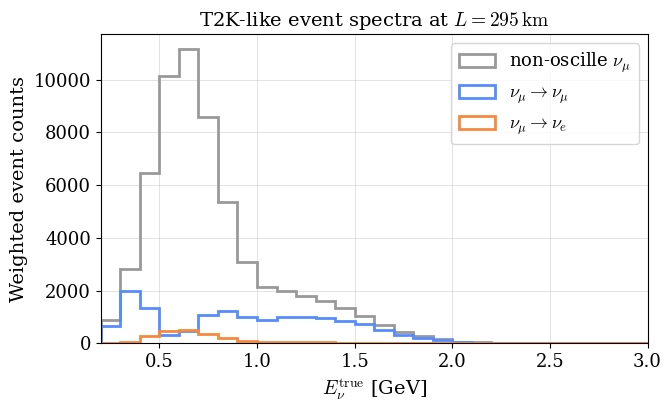

In [35]:
plt.figure(figsize=(7.0, 4.4))
plt.hist(
    E_nu_true,
    bins=hist_bins,
    histtype="step",
    linewidth=2.0,
    color="0.6",
    label=r"non-oscille $\nu_\mu$",
)
plt.hist(
    E_nu_true,
    bins=hist_bins,
    weights=P_numu_to_numu,
    histtype="step",
    linewidth=2.0,
    label=r"$\nu_\mu \rightarrow \nu_\mu$",
)
plt.hist(
    E_nu_true,
    bins=hist_bins,
    weights=P_numu_to_nue,
    histtype="step",
    linewidth=2.0,
    label=r"$\nu_\mu \rightarrow \nu_e$",
)
plt.xlabel(r"$E_{\nu}^{\mathrm{true}}$ [GeV]")
plt.ylabel("Weighted event counts")
plt.title(r"T2K-like event spectra at $L=295\,\mathrm{km}$")
plt.xlim(E_min, E_max)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
